# Homework 6: Neural Networks
**Name:** Nicholas Starace  
**Student ID:** 4556822  
**D Value:** 22  

## Question 1: Conceptual Foundations

### Part A: Why Neural Networks?

**Written Response:** In homework 3, a logistic regression classifier was trained and implemented to predict if students were admitted or not admitted based on two of their exam scores. Using the sigmoid function, a linear decsion boundary was formed in part 1(g). This classifier had poor accuracy, correctly predicting admission with 60% accuracy in part 1(h). A nonlinear decision boundary may improve this accuracy, acheved with nonlinear models such as a neural network that creates new features as a nonlinear function of the input scores.  

### Part B: The Sigmoid's Role

**Written Response:**  
1. The dimension of Theta_1 is 3 rows by 5 columns. This theta has superscript 1 since it connects the weights from the first input layer to the second (hidden) layer. Number of rows are characterized by the number of nodes in the destination (hidden) layer. The number of columns are characterized by the number of nodes in the source (input) layer + 1 due to the bias feature.  
The dimension of Theta_2 is 2 rows by 4 columns. This theta has superscript 2 since it connects the weights from the second (hidden) layer to the third (output) layer. Number of rows are characterized by the number of nodes in the destination (output) layer. The number of columns are characterized by the number of nodes in the source (hidden) layer + 1 due to the bias feature.  
2. The sigmoid function introduces nonlinearity into the network, creating new hidden nodes as nonlinear functions of the input nodes determined by the sigmoid function selected. Without the sigmoid function, nodes in the hidden layer would be linear functions of the input nodes. Using this directly makes the classifier nearly identical to a logistic regression since the hidden layer nodes would be a weighted sum of the input layer nodes. 

### Part C: Forward vs. Backward

**Written Response:**  
1. During forward propogation, weights connecting each source to destination node are computed as a sigmoid function of the weighted sum. After the weighted sum is calculated, its sum is used as the input to the sigmoid function. The output of the sigmod function determines the values of the nodes in the destination layer.  
2. During back propagation, the neural network is trained by finding the error in the output layer and and using the chain rule to find the origin node of the error. These gradients are used to perform gradient descent and update weights and errors.  
3. Without forward propagation, the optimal theta matrices will never be computed. Due to the calulation of the sigmoid function in forward propagation, new errors are updated and minimized at the end of forward propagation. 

## Question 2: Building the Network Components

### Part A: Sigmoid and Sigmoid Gradient

In [3]:
# Import Libraries and Parameter Initialization
import numpy as np
D = 22

In [4]:
# Sigmoid Function
def sigmoid(z):
    g = 1 / (1 + np.exp(-z))                
    return g

In [5]:
# Sigmoid Gradient
def sigmoidGradient(z):
    g = sigmoid(z)
    dg = g * (1 - g)
    return dg

In [6]:
# Test and Verify Sigmoid Gradient
z = np.array([[-10], [0], [10]]) # [1 x 3]
zout = sigmoidGradient(z)
print(zout)

# Test and Verfy with D value
z = np.array([[-D/5], [0], [D/5]])
zout = sigmoidGradient(z)
print(zout)

[[4.53958077e-05]
 [2.50000000e-01]
 [4.53958077e-05]]
[[0.01198134]
 [0.25      ]
 [0.01198134]]


**Text Output:** Sigmoid gradient for z: [0.012; 0.25; 0.012]

### Part B: Forward Propagation

In [ ]:
def predict(Theta1, Theta2, X):
    numSamples = X.shape[0]

    # Append Bias Column
    bias1 = np.ones((numSamples, 1)) 
    A1 = np.hstack((bias1, X))                # Add bias feature
    
    # Hidden Layer
    Z2 = A1 @ Theta1.T                        # Transpose to match dimensions
    A2 = sigmoid(Z2)

    # Output Layer
    bias2 = np.ones((numSamples, 1))
    A2_biased = np.hstack((bias2, A2))        # (numSamples x hiddenUnitsWithBias)

    Z3 = A2_biased @ Theta2.T                 # (numSamples x outputUnits)
    A3 = sigmoid(Z3)                          # (numSamples x outputUnits)

    p = np.argmax(A3, axis=1)                 # predicted class per sample

    return p, A3

### Part C: Verification with Toy Data

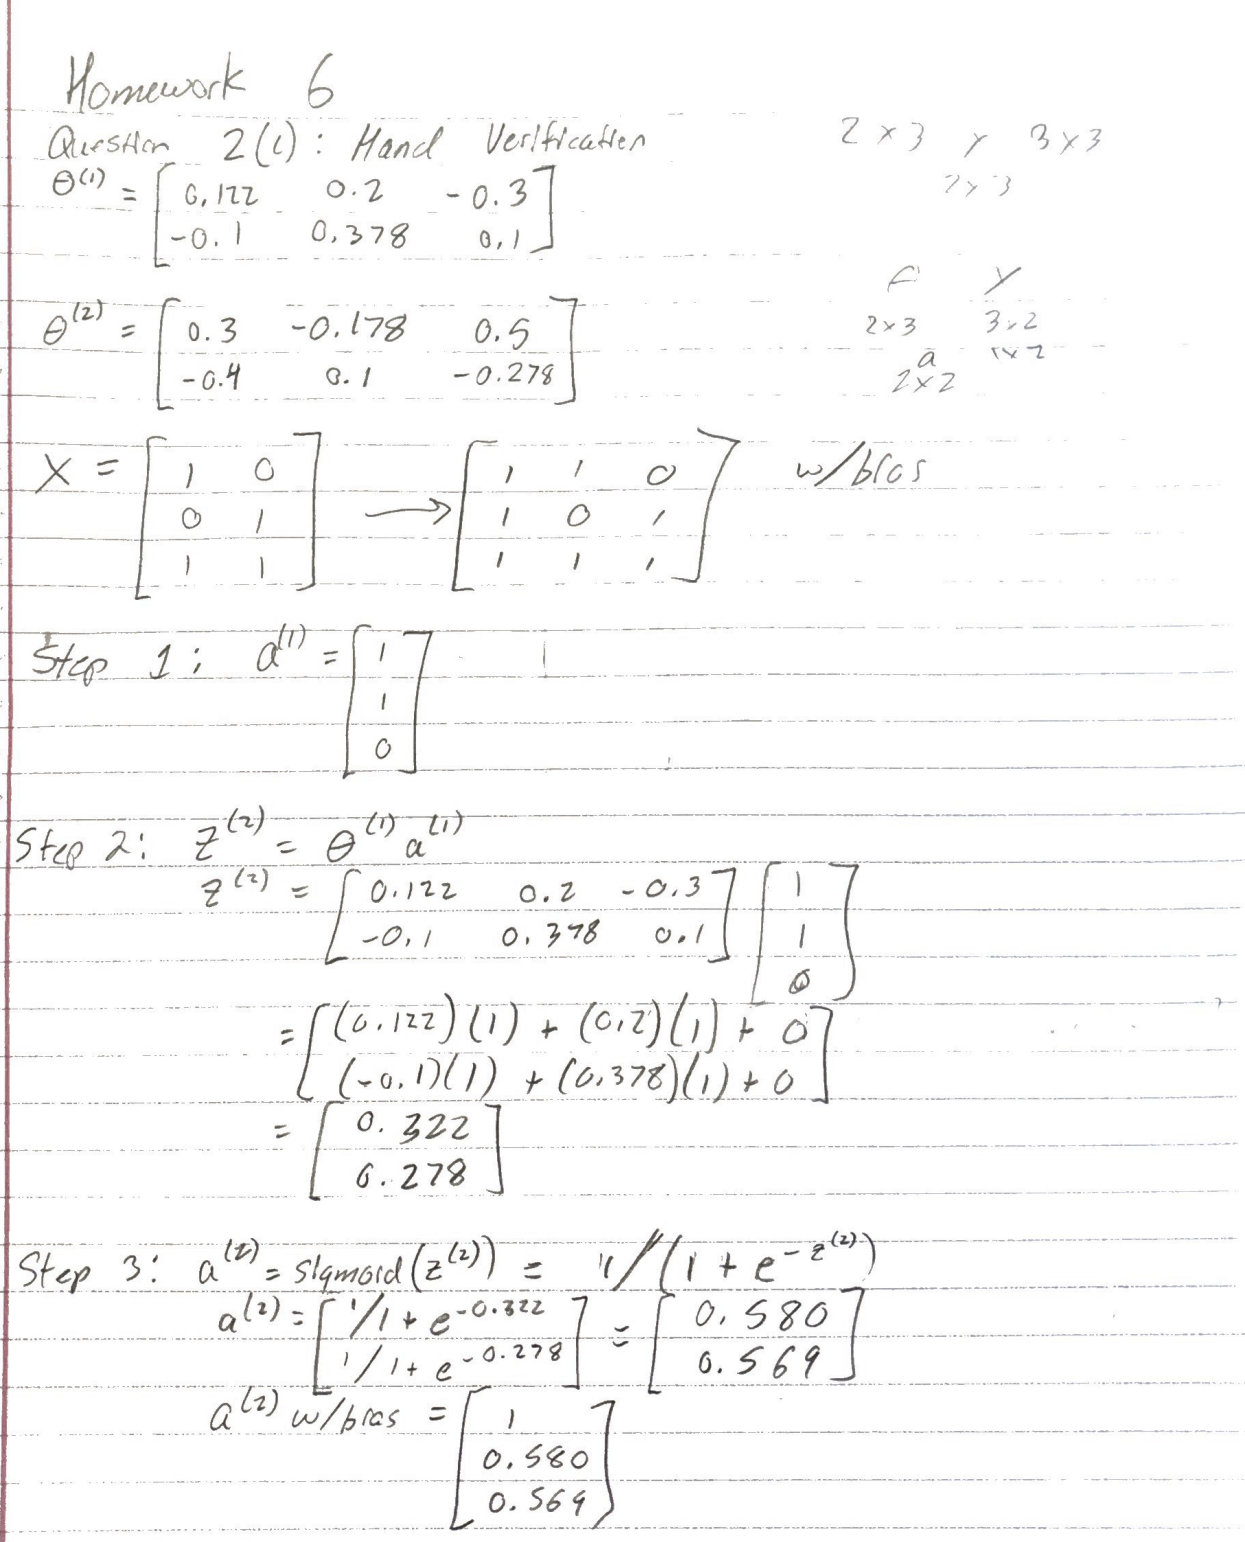  
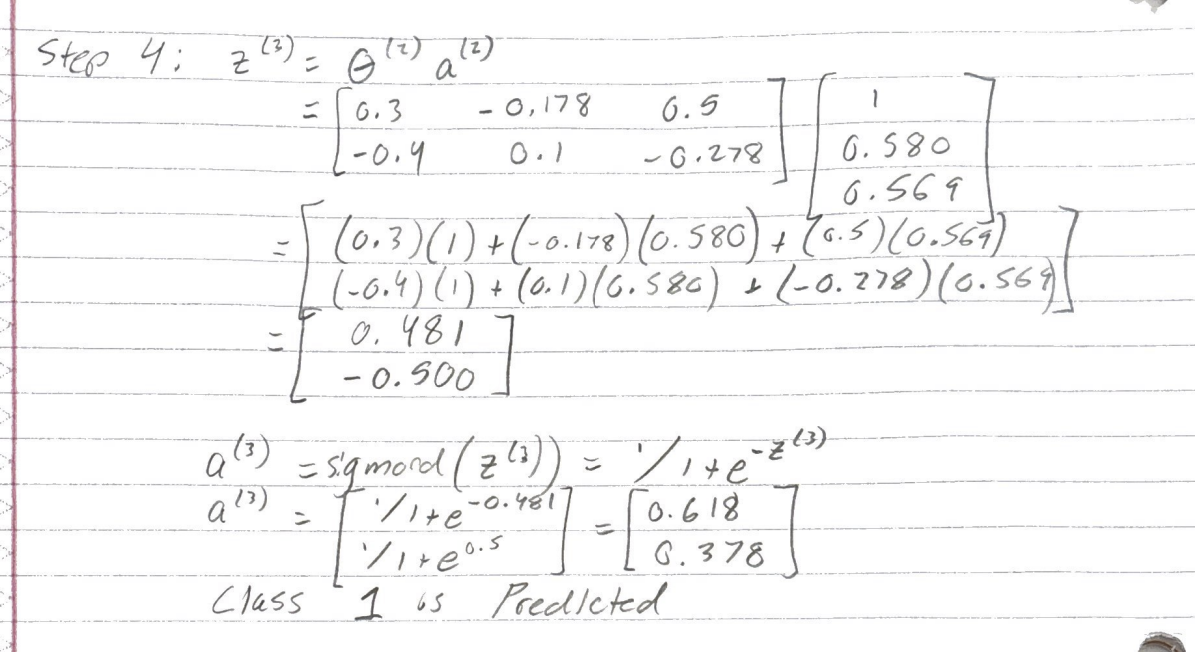

In [ ]:
# Test Predict on Toy Data
Theta1_toy = np.array([[0.1 + (D/1000), 0.2, -0.3], [-0.1, 0.4 - (D/1000), 0.1]])
Theta2_toy = np.array([[0.3, -0.2 + (D/1000), 0.5], [-0.4, 0.1, -0.3 + (D/1000)]])
X_toy = np.array([[1, 0], [0, 1], [1, 1]])

# Run Pretrained Theta for Forward Propagation
p, h_x = predict(Theta1_toy, Theta2_toy, X_toy)
print(h_x)


[[0.61805987 0.37748982]
 [0.6151234  0.37908393]
 [0.6240364  0.37415968]]


**Written Response:** Results from hand calcuations and the predict function agree. Both implementations yeild the probability of the first sample belonging to the first class = 0.62 and probability of belonging to the second class = 0.37

### Part D: Cost Function

In [ ]:
def nnCost(Theta1, Theta2, X, y, K, lambda_val):
    numSamples = X.shape[0]

    # Forward propagation
    _, h = predict(Theta1, Theta2, X)                               # h is (numSamples x numClasses)

    # Setup ouput one-hot encoding
    Y = np.zeros((numSamples, K))
    for i in range(numSamples):
        Y[i, y[i]] = 1                                              # Each sample, change appropriate column to class label

    # First Term Calculation
    entropy = np.sum(Y * np.log(h) + (1 - Y) * np.log(1 - h))       # Elementwise across classes, sum function across samples
    entropy = (-1 / numSamples) * entropy

    # Second Term Regularization
    reg = (lambda_val / (2 * numSamples)) * (
        np.sum(Theta1[:, 1:] ** 2) +                                # exclude bias column
        np.sum(Theta2[:, 1:] ** 2)
    )

    # Full Cost
    J = entropy + reg
    return J

In [10]:
# Test and Verify Cost Function
y_toy = np.array([1, 2, 1])
y_toy_0th= y_toy - 1        # Index from 0
K = 2                       # Number of classes

lambda_val = 0
J = nnCost(Theta1_toy, Theta2_toy, X_toy, y_toy_0th, K, lambda_val)
print(J)

lambda_val = 0.1
J = nnCost(Theta1_toy, Theta2_toy, X_toy, y_toy_0th, K, lambda_val)
print(J)

1.273400675726394
1.2842648757263941


**Written Response:**  
Cost when lambda = 0: 1.279  
Cost when lambda = 0.1: 1.289  
Both costs fall in the expected range. Regularized cost must always be >= unregularized because unregularized will always overfit to train the model exactly to the data it sees.

## Question 3: Backpropagation and Training

### Part A: Understanding Backpropagation

**Written Response:** Error for a given node is equal to node activation (a) - output (y). Since the bias term is fixed at 1, the activation for the bias term is also a constant equal to 1. The bias term is not a function of any learned weights. Since the goal of backpropagation is to "blame" a nodes weights to adjust and update, including the error from the bias term would spread blame to a constant node. 

### Part B: Implementing SGD with Backpropagation

In [ ]:
def sGD(input_layer_size, hidden_layer_size, num_labels, X_train, y_train, lambda_val, alpha, MaxEpochs, random_seed):
    
    # Dataset Dimensions
    numSamples = X_train.shape[0]
    K = num_labels

    # One-hot Encode Output
    Y = np.zeros((numSamples, K))
    for i in range(numSamples):
        Y[i, y_train[i]] = 1              # Each sample, change appropriate column to class label


    # Generate Initial Theta
    np.random.seed(random_seed)
    Theta1 = np.random.uniform(-0.15, 0.15, (hidden_layer_size, input_layer_size + 1)) # + 1 for bias node
    Theta2 = np.random.uniform(-0.15, 0.15, (K, hidden_layer_size + 1))

    cost_history = np.zeros(MaxEpochs)

    # Iterate Through Dataset
    for epoch in range(MaxEpochs):

        # Forward Propagation
        bias1 = np.ones((numSamples, 1)) 
        A1 = np.hstack((bias1, X_train))            # Append bias feature
        
        # Hidden Layer
        Z2 = A1 @ Theta1.T                          # Transpose to match dimensions
        A2 = sigmoid(Z2)

        # Output Layer
        bias2 = np.ones((numSamples, 1))
        A2_biased = np.hstack((bias2, A2))          # (numSamples x hiddenUnitsWithBias)

        Z3 = A2_biased @ Theta2.T                   # (numSamples x outputUnits)
        A3 = sigmoid(Z3)                            # (numSamples x outputUnits)


        # Backwards Propagation
        delta3 = A3 - Y
        delta2 = (delta3 @ Theta2[:, 1:]) * (A2 * (1 - A2))     # Don't include bias

        # Compute Gradient
        D2 = (delta3.T @ A2_biased) / numSamples                # Gradient
        D2[:, 1:] += (lambda_val / numSamples) * Theta2[:, 1:]  # Disregard Bias
        
        D1 = (delta2.T @ A1) / numSamples                       # First layer
        D1[:, 1:] += (lambda_val / numSamples) * Theta1[:, 1:]

        # Update Weight
        Theta2 = Theta2 - (alpha * D2)
        Theta1 = Theta1 - (alpha * D1)

        # Compue Cost
        J = nnCost(Theta1, Theta2, X_train, y_train, K, lambda_val)
        cost_history[epoch] = J # Store cost for current epoch

    return Theta1, Theta2, cost_history

### Part C: Verification on Toy Data

50.0


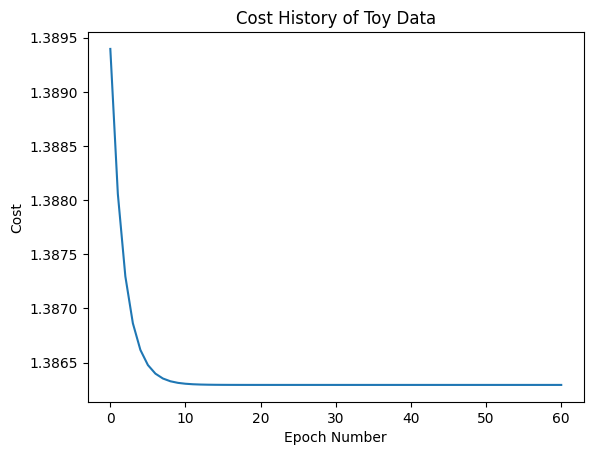

In [12]:
import matplotlib.pyplot as plt

X_verify = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y_verify = np.array([1, 2, 2, 1])
y_verify0th = y_verify - 1              # Index from 0

# NN Dimensions
input_layer_size = 2
hidden_layer_size = 4
num_labels = 2
alpha = 0.5
lambda_val = 0
MaxEpochs = 50 + int(np.floor(D/2))
random_seed = D

# Run NN
Theta1, Theta2, cost_history = sGD(input_layer_size, hidden_layer_size, num_labels, X_verify, y_verify0th, lambda_val, alpha, MaxEpochs, random_seed)

# Plot Cost History
EpochX = np.arange(MaxEpochs) # Generate Vector of indices for plotting
plt.plot(EpochX, cost_history)
plt.xlabel("Epoch Number")
plt.ylabel("Cost")
plt.title("Cost History of Toy Data")

# Compute Accuracy
p, A3 = predict(Theta1, Theta2, X_verify)
p = p + 1 # Convert back to indexing from 1

TotalCorr = (y_verify == p).sum()
Acc = (TotalCorr / len(y_verify)) * 100
print(Acc)

**Written Response:** Cost decreases from the first epoch until epoch ~12 when the cost stabilizes at 1.386.  
The final cost = 1.38629 with training accuracy = %50  
Changing the seed doesn't affect training accuracy.  
Results of this poor accuracy indicate that training under the range given for the random unform distribution converge at a local minimum for theta. The absolute minimum is somewhere outside of the random interval given. 

## Question 4: Dataset A - Iris Classification

### Part A: Data Exploration and Pre-Trained Verification

H = 9

In [ ]:
import scipy.io

# Network Architecture
H = 5 + (D % 6) # = 9
input_layer_size = 3
hidden_layer_size = H
num_labels = 3

# Load Dataset
data = scipy.io.loadmat('input/ps6_iris.mat')
X = np.array(data['X'])
y = np.array(data['y'])
y = y.ravel()
print(X.shape)
print(y.shape)

# Find Number of Samples in each Class
numy1 = (y == 1).sum()
numy2 = (y == 2).sum()
numy3 = (y == 3).sum()
print(numy1)
print(numy2)
print(numy3)

(150, 4)
(150,)
50
50
50


Dimensions of X: [150 rows x 4 columns]  
Dimensions of y: [150 rows x 1 column]  
50 samples per class

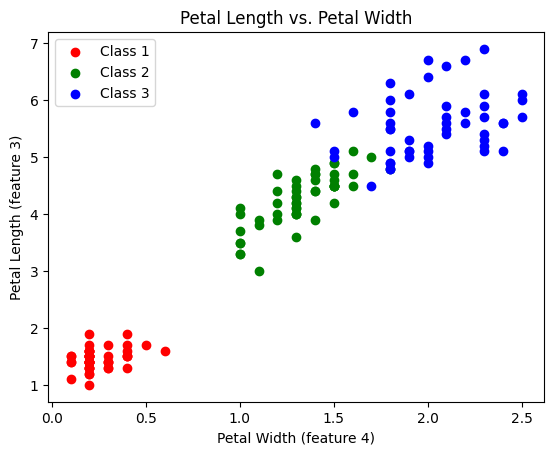

In [14]:
# Create Scatter Plot of petal length vs petal width
X1 = X[y==1, :] # Extract samples belonging to 1st class
X2 = X[y==2, :]
X3 = X[y==3, :]

plt.scatter(X1[:, 3], X1[:, 2], color="red", label="Class 1")
plt.scatter(X2[:, 3], X2[:, 2], color="green", label="Class 2")
plt.scatter(X3[:, 3], X3[:, 2], color="blue", label="Class 3")
plt.xlabel("Petal Width (feature 4)")
plt.ylabel("Petal Length (feature 3)")
plt.title("Petal Length vs. Petal Width")
plt.legend(loc="upper left")

In [ ]:
# Load Pre-Trained Weights
weightsPre = scipy.io.loadmat('input/ps6_iris_weights.mat')
Theta1Pre = weightsPre['Theta1']
Theta2Pre = weightsPre['Theta2']

# Test Predict Function on Real Data
p, A3 = predict(Theta1Pre, Theta2Pre, X)
p = p + 1                                   # Convert back to indexing from 1
TotalCorr = (y == p).sum()
Acc = (TotalCorr / len(y)) * 100
print(f"Accuracy = {Acc}%")

# Test Cost Function for lambda = 0, 1, 2
K = max(y)                                  # Number of classes
y0th = y - 1                                # Index from 0

lambda_val = 0
J = nnCost(Theta1Pre, Theta2Pre, X, y0th, K, lambda_val)
print(f"lambda = 0: J = {J}")

lambda_val = 1
J = nnCost(Theta1Pre, Theta2Pre, X, y0th, K, lambda_val)
print(f"lambda = 1: J = {J}")

lambda_val = 2
J = nnCost(Theta1Pre, Theta2Pre, X, y0th, K, lambda_val)
print(f"lambda = 2: J = {J}")


Accuracy = 98.0%
lambda = 0: J = 0.20252633908551312
lambda = 1: J = 1.0326189817073517
lambda = 2: J = 1.8627116243291904


**Written Response:**  
Accuracy = 98%  
Lambda = 0: J = 0.203  
Lambda = 1: J = 1.033
Lambda = 2: J = 1.863  
Based on the scatter plot, class 1 (red) is linearaly separable since all points in the given feature space occupy their own region. Class 2 and 3 are not linearly separable from one another since they overlap in the feature space. 

### Part B: Train/Test Split

In [16]:
# Split 85% train, 15% test
np.random.seed(D)
start = 0
mid = int(np.floor(X.shape[0] * 0.85))
end = X.shape[0]
randArr = np.random.permutation(X.shape[0])
X_train = X[randArr[start:mid], :]
X_test = X[randArr[mid:end], :]
y_train = y[randArr[start:mid]]
y_test = y[randArr[mid:end]]

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(127, 4)
(23, 4)
(127,)
(23,)


**Written Response:**  
Training Set: 127 Samples
Testing Set: 23 Samples

### Part C: Training and Evaluation

Accuracy Results
                             MaxEpochs = 50                        MaxEpochs = 100
                  alpha      Training           Testing            Training            Testing
                             Accuracy [%]       Accuracy [%]       Accuracy [%]        Accuracy [%]
lambda = 0       0.6         96.85              100.00             98.43               100.00
lambda = 0.01    0.6         96.85              100.00             98.43               100.00
lambda = 0.1     0.6         97.64              100.00             98.43               100.00
lambda = 1       0.6         97.64              100.00             98.43               100.00


Text(0.5, 1.0, 'Cost History lambda = 0.1, MaxEpochs = 100')

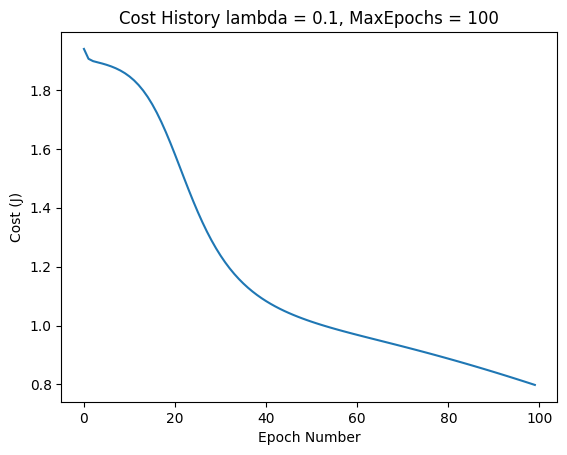

In [17]:
# NN Dimensions
input_layer_size = 4
hidden_layer_size = H
num_labels = 3
alpha = 0.6
MaxEpochs_all = np.array([50, 100])
random_seed = D
lambda_all = np.array([0, 0.01, 0.1, 1])

# Store Results
Acc = np.zeros((4, 4))

# Iterate over Lambda
for i in range(4):
    lambda_val = lambda_all[i]

    # Index y from 0
    y0th_train = y_train - 1 

    # Iterate over Epoch Num
    j = 0
    for j in range(2):
        MaxEpochs = MaxEpochs_all[j]

        # Accuracy Matrix Indexing
        if j == 0: 
            r = 0
            c = 1
        elif j == 1: 
            r = r + 2
            c = c + 2
        
        # Train NN
        Theta1, Theta2, cost_history = sGD(input_layer_size, hidden_layer_size, num_labels, X_train, y0th_train, lambda_val, alpha, MaxEpochs, random_seed)

        # Compute Training Accuracy
        p, A3 = predict(Theta1, Theta2, X_train)
        p = p + 1 # Convert back to indexing from 1

        TotalCorr = (y_train == p).sum()
        Acc[i, r] = (TotalCorr / len(y_train)) * 100

        # Compute Testing Accuracy
        p, A3 = predict(Theta1, Theta2, X_test)
        p = p + 1
        TotalCorr = (y_test == p).sum()
        Acc[i, c] = (TotalCorr / len(y_test)) * 100

# Display Accuracy Results
print("Accuracy Results")
print("                             MaxEpochs = 50                        MaxEpochs = 100")
print("                  alpha      Training           Testing            Training            Testing")
print("                             Accuracy [%]       Accuracy [%]       Accuracy [%]        Accuracy [%]")
print(f"lambda = 0       {alpha}         {Acc[0,0]:.2f}              {Acc[0,1]:.2f}             {Acc[0,2]:.2f}               {Acc[0,3]:.2f}")
print(f"lambda = 0.01    {alpha}         {Acc[1,0]:.2f}              {Acc[1,1]:.2f}             {Acc[1,2]:.2f}               {Acc[1,3]:.2f}")  
print(f"lambda = 0.1     {alpha}         {Acc[2,0]:.2f}              {Acc[2,1]:.2f}             {Acc[2,2]:.2f}               {Acc[2,3]:.2f}")
print(f"lambda = 1       {alpha}         {Acc[3,0]:.2f}              {Acc[3,1]:.2f}             {Acc[3,2]:.2f}               {Acc[3,3]:.2f}")

# Plot Best Result (lambda = 0.1, MaxEpochs = 100)
lambda_val = 0.1
MaxEpochs = 100
Theta1, Theta2, cost_history = sGD(input_layer_size, hidden_layer_size, num_labels, X_train, y0th_train, lambda_val, alpha, MaxEpochs, random_seed)
EpochVec = np.arange(MaxEpochs)
plt.plot(EpochVec, cost_history)
plt.xlabel("Epoch Number")
plt.ylabel("Cost (J)")
plt.title("Cost History lambda = 0.1, MaxEpochs = 100")

**Written Response:** While all combinaions achieve 100% testing accuracy, the best choice would utilize regularization to make the model robust for generalization with lambda = 0.01 or 0.1. The best learning rate is 0.6 and higher number of epochs make the testing accuracy better. There is a gap between testing and training accuracy across all trials where testing accuracy is lower than training accuracy. While not large, this gap suggests that the model could benefit from traning on a larger number of epochs.  

## Question 5: Dataset B - Vehicle Image Classification

### Part A: Dataset Exploration

(15000, 1024)
(15000,)
5000
5000
5000


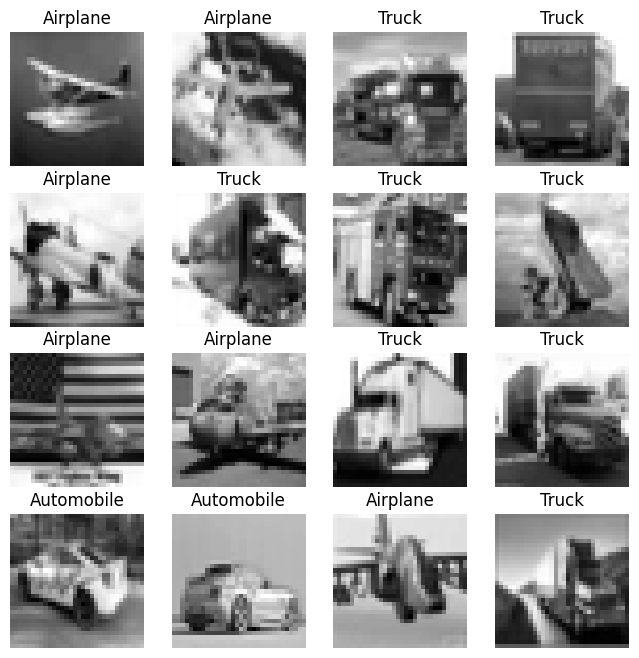

In [18]:
# Network Architecture
H = 30 + (D % 20)
input_layer_size = 1024
hidden_layer_size = H
num_labels = 3

# Load Dataset
data = scipy.io.loadmat('input/ps6_vehicles.mat')
X = np.array(data['X'])
y = np.array(data['y_labels'])
y = y.ravel()
print(X.shape)
print(y.shape)

numy1 = (y == 1).sum()
numy2 = (y == 2).sum()
numy3 = (y == 3).sum()
print(numy1)
print(numy2)
print(numy3)

# Decode Class Names
labels = np.array(["Airplane", "Automobile", "Truck"])

# Randomly Select 16 Images
np.random.seed(D)
start = 0
mid = 16
end = X.shape[0]
randArr = np.random.permutation(X.shape[0])
X_show = X[randArr[start:mid], :]
y_show = y[randArr[start:mid]]

# Iterate to display images
plt.figure(figsize=(8, 8))
for i in range(16):
    img = X_show[i, :].reshape(32, 32, order='F')
    classlabel = labels[y_show[i] - 1]  # -1 since indexed from 0

    plt.subplot(4, 4, i + 1)
    plt.imshow(img, cmap='gray')
    plt.title(f"{classlabel}")
    plt.axis("off")



Dimensions of X: [15000 samples x 1024 features]  
Dimensions of y: [15000 samples x 1 output class]  
Samples per class: 5000


**Written Response:** As a human, it is possible but somewhat difficult to distinguish between Airplanes and cars/trucks and more difficult specifically to distinguish between automobiles and trucks. For a human, classifying these objects require specific knowledge such as car height, truck trailing capabilities, or sky background for suspended airplanes. These are features of the images that aren't linear or uniform, making the classification problem difficult.   

### Part B: Training and Evaluation

In [19]:
# Split 13000 train, 2000 test
np.random.seed(D)
start = 0
mid = 13000
end = X.shape[0]
randArr = np.random.permutation(X.shape[0])
X_train = X[randArr[start:mid], :]
X_test = X[randArr[mid:end], :]
y_train = y[randArr[start:mid]]
y_test = y[randArr[mid:end]]

In [470]:
# NN Dimensions
input_layer_size = 1024
hidden_layer_size = H
num_labels = 3
alphaAll = np.array([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1, 1.1, 1.2, 1.3, 1.4, 1.50])
MaxEpochs_all = np.array([50, 150])
random_seed = D
lambda_all = np.array([0.01, 0.1, 0.2, 1])

for a in range(15):
    alpha = alphaAll[a]
    
    # Store Results
    Acc = np.zeros((4, 4))
    Cos = np.zeros((4, 2))

    # Iterate over Lambda
    for i in range(4):
        lambda_val = lambda_all[i]

        # Index y from 0
        y0th_train = y_train - 1 

        # Iterate over Epoch Num
        j = 0
        for j in range(2):
            MaxEpochs = MaxEpochs_all[j]

            # Accuracy Matrix Indexing
            if j == 0: 
                r = 0
                c = 1
            elif j == 1: 
                r = r + 2
                c = c + 2
            
            # Train NN
            Theta1, Theta2, cost_history = sGD(input_layer_size, hidden_layer_size, num_labels, X_train, y0th_train, lambda_val, alpha, MaxEpochs, random_seed)
            Cos[i, j] = cost_history[MaxEpochs - 1] # Store cost

            # Compute Training Accuracy
            p, A3 = predict(Theta1, Theta2, X_train)
            p = p + 1 # Convert back to indexing from 1

            TotalCorr = (y_train == p).sum()
            Acc[i, r] = (TotalCorr / len(y_train)) * 100

            # Compute Testing Accuracy
            p, A3 = predict(Theta1, Theta2, X_test)
            p = p + 1
            TotalCorr = (y_test == p).sum()
            Acc[i, c] = (TotalCorr / len(y_test)) * 100

    # Display Accuracy Results
    print("Accuracy Results")
    print("                             MaxEpochs = 50                        MaxEpochs = 100")
    print("                  alpha      Training           Testing            Training            Testing")
    print("                             Accuracy [%]       Accuracy [%]       Accuracy [%]        Accuracy [%]")
    print(f"lambda = 0       {alpha}         {Acc[0,0]:.2f}              {Acc[0,1]:.2f}             {Acc[0,2]:.2f}               {Acc[0,3]:.2f}")
    print(f"lambda = 0.01    {alpha}         {Acc[1,0]:.2f}              {Acc[1,1]:.2f}             {Acc[1,2]:.2f}               {Acc[1,3]:.2f}")  
    print(f"lambda = 0.1     {alpha}         {Acc[2,0]:.2f}              {Acc[2,1]:.2f}             {Acc[2,2]:.2f}               {Acc[2,3]:.2f}")
    print(f"lambda = 1       {alpha}         {Acc[3,0]:.2f}              {Acc[3,1]:.2f}             {Acc[3,2]:.2f}               {Acc[3,3]:.2f}")

# Display Cost Results
print("Cost Results")
print("                             MaxEpochs = 50                        MaxEpochs = 100")
print("                  alpha      Training           Testing            Training            Testing")
print("                             Cost [%]           Cost [%]           Cost [%]            Cost [%]")
print(f"lambda = 0       {alpha}         {Cos[0,0]:.2f}                                   {Cos[0,1]:.2f}               ")
print(f"lambda = 0.01    {alpha}         {Cos[1,0]:.2f}                                   {Cos[1,1]:.2f}               ")  
print(f"lambda = 0.1     {alpha}         {Cos[2,0]:.2f}                                   {Cos[2,1]:.2f}               ")
print(f"lambda = 1       {alpha}         {Cos[3,0]:.2f}                                   {Cos[3,1]:.2f}               ")

# Plot Best Result (lambda = 0.1, MaxEpochs = 100)
lambda_val = 0.1
MaxEpochs = 100
Theta1, Theta2, cost_history = sGD(input_layer_size, hidden_layer_size, num_labels, X_train, y0th_train, lambda_val, alpha, MaxEpochs, random_seed)
EpochVec = np.arange(MaxEpochs)
#plt.plot(EpochVec, cost_history)
#plt.xlabel("Epoch Number")
#plt.ylabel("Cost (J)")
#plt.title("Cost History lambda = 0.1, MaxEpochs = 100")

Accuracy Results
                             MaxEpochs = 50                        MaxEpochs = 100
                  alpha      Training           Testing            Training            Testing
                             Accuracy [%]       Accuracy [%]       Accuracy [%]        Accuracy [%]
lambda = 0       0.1         49.69              48.45             55.42               56.90
lambda = 0.01    0.1         49.69              48.45             55.42               56.90
lambda = 0.1     0.1         49.69              48.45             55.42               56.90
lambda = 1       0.1         49.68              48.45             55.43               56.90
Accuracy Results
                             MaxEpochs = 50                        MaxEpochs = 100
                  alpha      Training           Testing            Training            Testing
                             Accuracy [%]       Accuracy [%]       Accuracy [%]        Accuracy [%]
lambda = 0       0.2         54.17        

KeyboardInterrupt: 

Note: Cell above used to iterate through alpha. Interupted once best alpha found.

In [30]:
# NN Dimensions
input_layer_size = 1024
hidden_layer_size = H
num_labels = 3
alpha = 0.1
MaxEpochs_all = np.array([50, 150])
random_seed = D
lambda_all = np.array([0.01, 0.1, 0.2, 1])

# Store Results
Acc = np.zeros((4, 4))
Cos = np.zeros((4, 2))

# Iterate over Lambda
for i in range(4):
    lambda_val = lambda_all[i]

    # Index y from 0
    y0th_train = y_train - 1 

    # Iterate over Epoch Num
    j = 0
    for j in range(2):
        MaxEpochs = MaxEpochs_all[j]

        # Accuracy Matrix Indexing
        if j == 0: 
            r = 0
            c = 1
        elif j == 1: 
            r = r + 2
            c = c + 2
        
        # Train NN
        Theta1, Theta2, cost_history = sGD(input_layer_size, hidden_layer_size, num_labels, X_train, y0th_train, lambda_val, alpha, MaxEpochs, random_seed)
        Cos[i, j] = cost_history[MaxEpochs - 1] # Store cost

        # Compute Training Accuracy
        p, A3 = predict(Theta1, Theta2, X_train)
        p = p + 1 # Convert back to indexing from 1

        TotalCorr = (y_train == p).sum()
        Acc[i, r] = (TotalCorr / len(y_train)) * 100

        # Compute Testing Accuracy
        p, A3 = predict(Theta1, Theta2, X_test)
        p = p + 1
        TotalCorr = (y_test == p).sum()
        Acc[i, c] = (TotalCorr / len(y_test)) * 100

Accuracy Results
                             MaxEpochs = 50                        MaxEpochs = 150
                  alpha      Training           Testing            Training            Testing
                             Accuracy [%]       Accuracy [%]       Accuracy [%]        Accuracy [%]
lambda = 0.01     0.1         49.69              48.45             55.42               56.90
lambda = 0.1      0.1         49.69              48.45             55.42               56.90
lambda = 0.2      0.1         49.69              48.45             55.42               56.90
lambda = 1        0.1         49.68              48.45             55.43               56.90
Cost Results
                             MaxEpochs = 50                        MaxEpochs = 150
                  alpha      Training           Testing            Training            Testing
                             Cost [%]           Cost [%]           Cost [%]            Cost [%]
lambda = 0.01     0.1         1.88            

Text(0.5, 1.0, 'Cost History lambda = 0.2, MaxEpochs = 150')

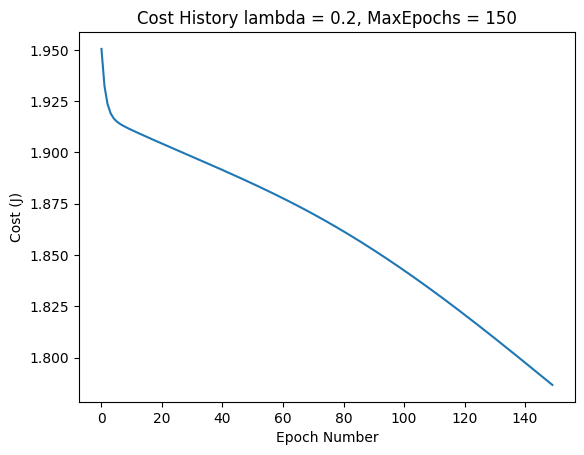

In [31]:
# Display Accuracy Results
print("Accuracy Results")
print("                             MaxEpochs = 50                        MaxEpochs = 150")
print("                  alpha      Training           Testing            Training            Testing")
print("                             Accuracy [%]       Accuracy [%]       Accuracy [%]        Accuracy [%]")
print(f"lambda = 0.01     {alpha}         {Acc[0,0]:.2f}              {Acc[0,1]:.2f}             {Acc[0,2]:.2f}               {Acc[0,3]:.2f}")
print(f"lambda = 0.1      {alpha}         {Acc[1,0]:.2f}              {Acc[1,1]:.2f}             {Acc[1,2]:.2f}               {Acc[1,3]:.2f}")  
print(f"lambda = 0.2      {alpha}         {Acc[2,0]:.2f}              {Acc[2,1]:.2f}             {Acc[2,2]:.2f}               {Acc[2,3]:.2f}")
print(f"lambda = 1        {alpha}         {Acc[3,0]:.2f}              {Acc[3,1]:.2f}             {Acc[3,2]:.2f}               {Acc[3,3]:.2f}")

# Display Cost Results
print("Cost Results")
print("                             MaxEpochs = 50                        MaxEpochs = 150")
print("                  alpha      Training           Testing            Training            Testing")
print("                             Cost [%]           Cost [%]           Cost [%]            Cost [%]")
print(f"lambda = 0.01     {alpha}         {Cos[0,0]:.2f}                                   {Cos[0,1]:.2f}               ")
print(f"lambda = 0.1      {alpha}         {Cos[1,0]:.2f}                                   {Cos[1,1]:.2f}               ")  
print(f"lambda = 0.2      {alpha}         {Cos[2,0]:.2f}                                   {Cos[2,1]:.2f}               ")
print(f"lambda = 1        {alpha}         {Cos[3,0]:.2f}                                   {Cos[3,1]:.2f}               ")

# Plot Best Result (lambda = 0.1, MaxEpochs = 100)
alpha = 0.1
lambda_val = 0.2
MaxEpochs = 150
Theta1, Theta2, cost_history = sGD(input_layer_size, hidden_layer_size, num_labels, X_train, y0th_train, lambda_val, alpha, MaxEpochs, random_seed)
EpochVec = np.arange(MaxEpochs)
plt.plot(EpochVec, cost_history)
plt.xlabel("Epoch Number")
plt.ylabel("Cost (J)")
plt.title("Cost History lambda = 0.2, MaxEpochs = 150")

**Written Response:**  
Alpha = 0.1  
While higher alphas such as 0.8 yeilded higher testing accuracy, plotting the cost history showed large oscillations across epochs. Highest testing accuracy was about 57% across all regularization conditions and always performed better with more epochs. The low resolution of the images may be the reason for poor accuracy since it is difficult to select any feature, even for a human to classfiy. 

### Part D: Comparative Analysis and Reflection

**Written Response:**  
1. The approximate difference between Iris vs. Vehicles is close to 50% with Iris accuracy = 100% and Vehicles = 57%. The difference in performance across alphas was sharp in the Iris problem while Vehicle performance was about constant across all alphas tested. Additionally, the difference between testing and training accuracy was much larger in the Iris problem whereas the difference was close to zero in the Vehicles problem.  
2. The raw pixels are poor features because there is no image standard across all photos. Each image can have a different background, profile, shape, or orientation that has no affect on the classification. However, these large differences will be consdered by the network as notable features to determine classification. Unlike the vehicles, the iris data was standardized since each input feature was carefully selected against a measurement.  
3. The poor accuracy of the network on vehicles is due to the input features, not a bug or architecture. These input features being pixels have low correlation with output classes. As discussed earlier, these features don't follow any standardization. The Iris input feature equvalent would be classifying using generic photos of people where most of the photos are useless since it occupies background or other bodyparts.  
4. CNNs would improve the accuracy of the vehicle classification problem by preprocessing the pixel features. One benefit of CNNs would be filtering noise since they use a convolutional kernel that can be designed to pass parts of the vehicle and stop irrelevant pixels in the photo. Another benefit of CNNs is dimensionality reducton across each kernel convolution, therefore creating new input features that assist with curse of dimensionality.  
5. To improve network performance by only changing input features, one might perform Principal Component Analysis (PCA) since it can reduce the number of input features and will capture the maximum variance in the feature space. For example, if all backgrounds are black or white in the photo, PCA will essentially "throw away" these properties of the photo leaving more relevant features. PCA might also find large variance in the vehicle differences which will lead to prioritizing an eigenspace that captures vehicle properties.  